In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [2]:
df = pd.read_csv("./World_Happiness.csv")

## 1. Understanding the dataset

In [4]:
df.shape

(155, 12)

In [5]:
df.columns

Index(['Country', 'Happiness.Rank', 'Happiness.Score', 'Whisker.high',
       'Whisker.low', 'Economy..GDP.per.Capita.', 'Family',
       'Health..Life.Expectancy.', 'Freedom', 'Generosity',
       'Trust..Government.Corruption.', 'Dystopia.Residual'],
      dtype='str')

In [6]:
df.isnull().sum()

Country                          0
Happiness.Rank                   0
Happiness.Score                  0
Whisker.high                     0
Whisker.low                      0
Economy..GDP.per.Capita.         0
Family                           0
Health..Life.Expectancy.         0
Freedom                          0
Generosity                       0
Trust..Government.Corruption.    0
Dystopia.Residual                0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.head()

,Country,Happiness.Rank,Happiness.Score,Whisker.high,Whisker.low,Economy..GDP.per.Capita.,Family,Health..Life.Expectancy.,Freedom,Generosity,Trust..Government.Corruption.,Dystopia.Residual
0,Norway,1,7.537,7.594445,7.479556,1.616463,1.533524,0.796667,0.635423,0.362012,0.315964,2.277027
1,Denmark,2,7.522,7.581728,7.462272,1.482383,1.551122,0.792566,0.626007,0.355280,0.400770,2.313707
2,Iceland,3,7.504,7.622030,7.385970,1.480633,1.610574,0.833552,0.627163,0.475540,0.153527,2.322715
3,Switzerland,4,7.494,7.561772,7.426227,1.564980,1.516912,0.858131,0.620071,0.290549,0.367007,2.276716
4,Finland,5,7.469,7.527542,7.410458,1.443572,1.540247,0.809158,0.617951,0.245483,0.382612,2.430182


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 155 entries, 0 to 154
Data columns (total 12 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Country                        155 non-null    str    
 1   Happiness.Rank                 155 non-null    int64  
 2   Happiness.Score                155 non-null    float64
 3   Whisker.high                   155 non-null    float64
 4   Whisker.low                    155 non-null    float64
 5   Economy..GDP.per.Capita.       155 non-null    float64
 6   Family                         155 non-null    float64
 7   Health..Life.Expectancy.       155 non-null    float64
 8   Freedom                        155 non-null    float64
 9   Generosity                     155 non-null    float64
 10  Trust..Government.Corruption.  155 non-null    float64
 11  Dystopia.Residual              155 non-null    float64
dtypes: float64(10), int64(1), str(1)
memory usage: 14.7 KB


In [10]:
df.describe()

,Happiness.Rank,Happiness.Score,Whisker.high,Whisker.low,Economy..GDP.per.Capita.,Family,Health..Life.Expectancy.,Freedom,Generosity,Trust..Government.Corruption.,Dystopia.Residual
count,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000
mean,78.000000,5.354019,5.452326,5.255713,0.984718,1.188898,0.551341,0.408786,0.246883,0.123120,1.850238
std,44.888751,1.131230,1.118542,1.145030,0.420793,0.287263,0.237073,0.149997,0.134780,0.101661,0.500028
min,1.000000,2.693000,2.864884,2.521116,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.377914
25%,39.500000,4.505500,4.608172,4.374955,0.663371,1.042635,0.369866,0.303677,0.154106,0.057271,1.591291
50%,78.000000,5.279000,5.370032,5.193152,1.064578,1.253918,0.606042,0.437454,0.231538,0.089848,1.832910
75%,116.500000,6.101500,6.194600,6.006527,1.318027,1.414316,0.723008,0.516561,0.323762,0.153296,2.144654
max,155.000000,7.537000,7.622030,7.479556,1.870766,1.610574,0.949492,0.658249,0.838075,0.464308,3.117485


## 2. Outlier analysis

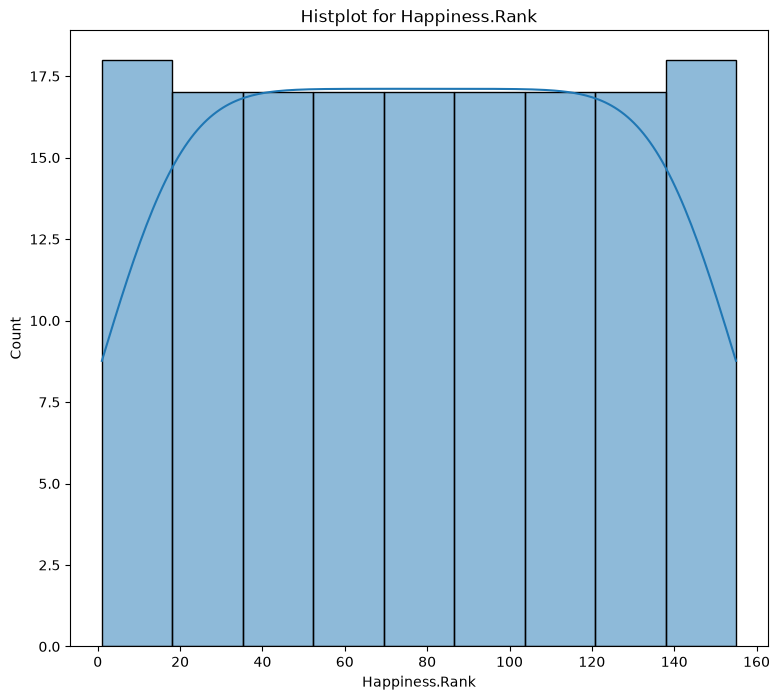

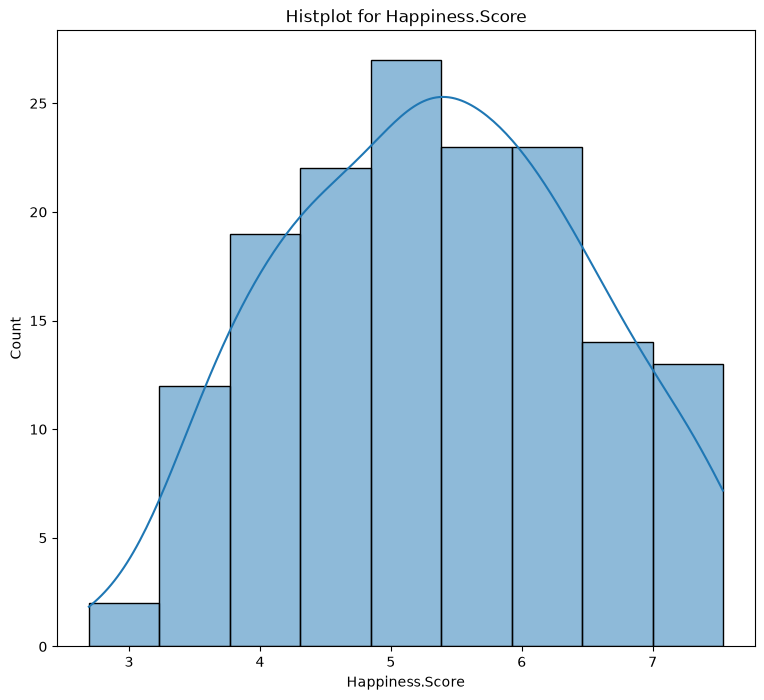

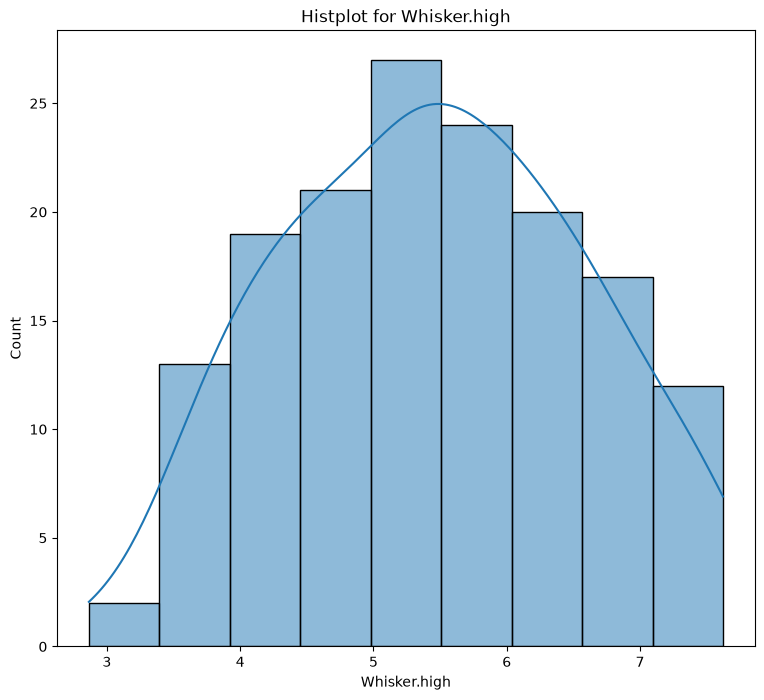

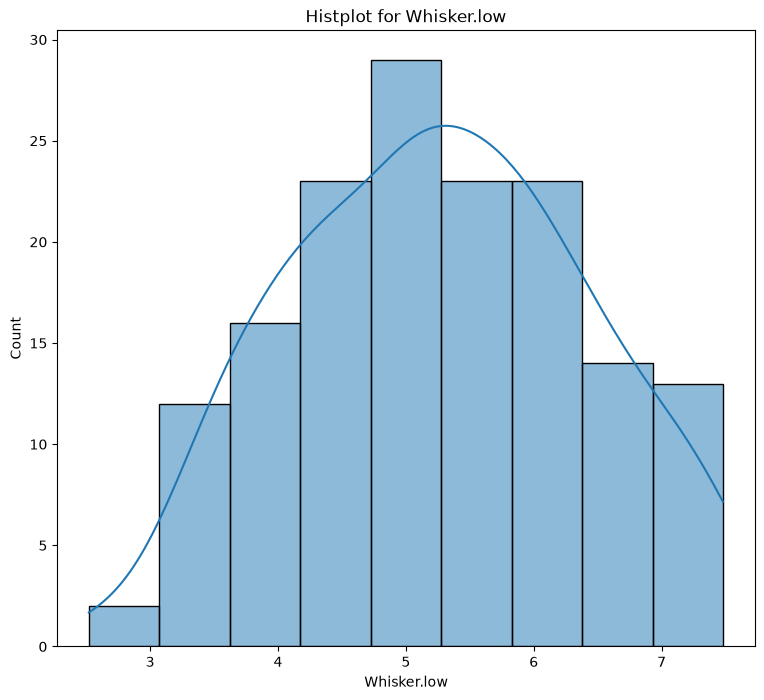

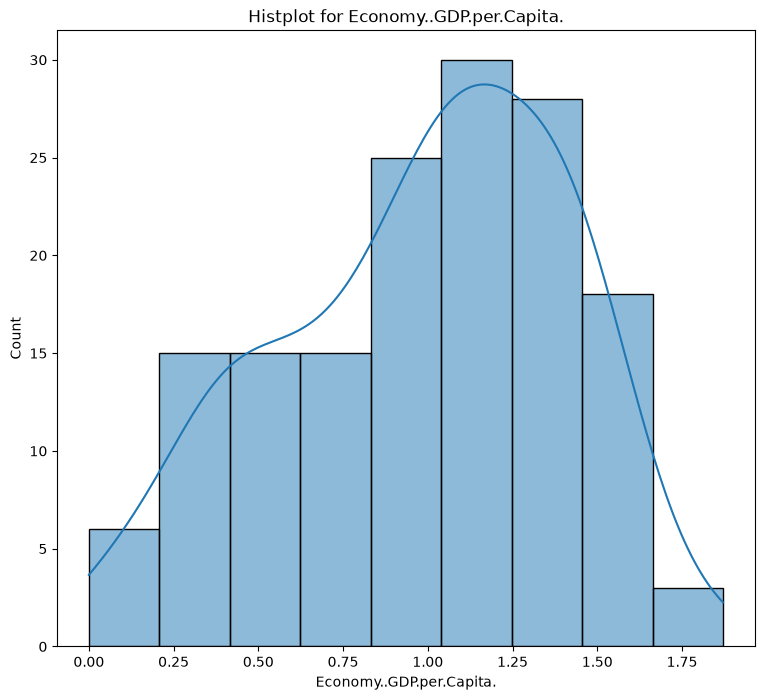

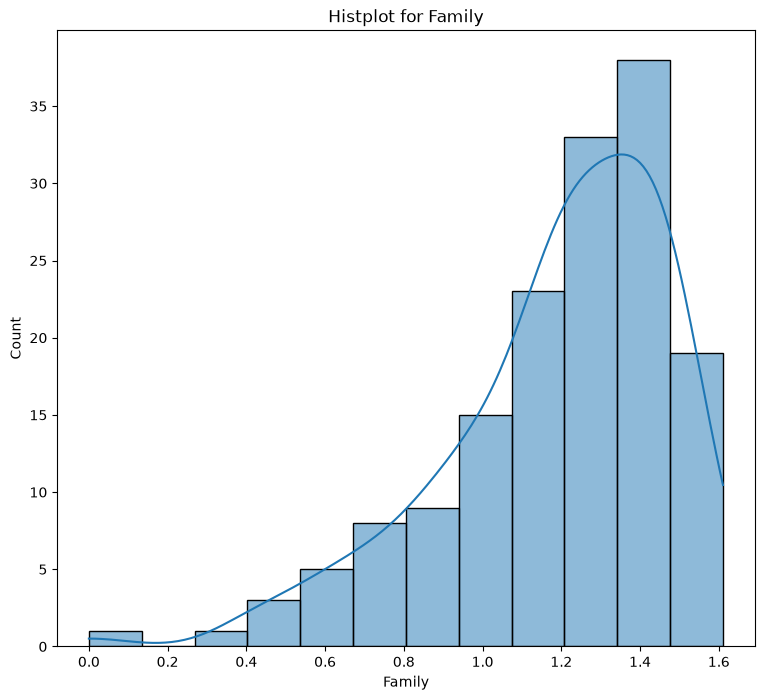

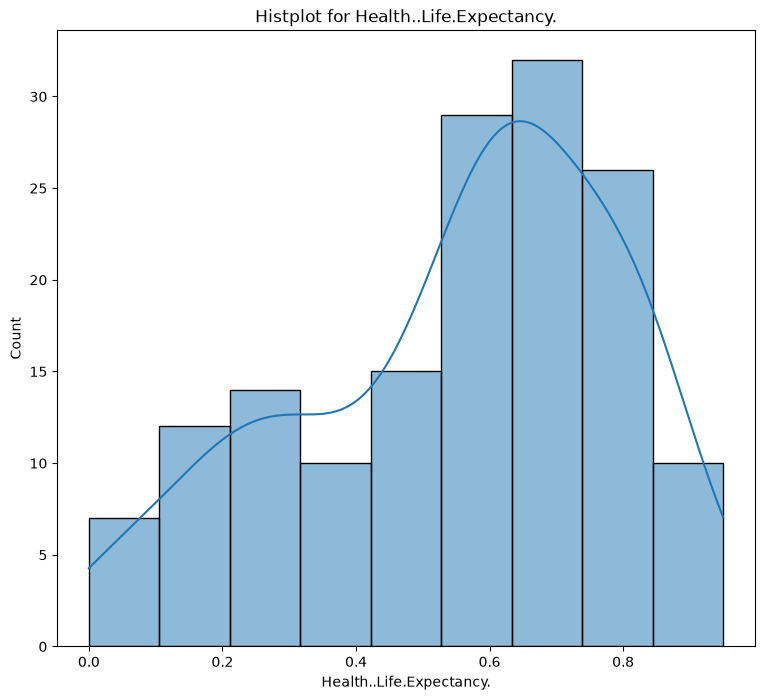

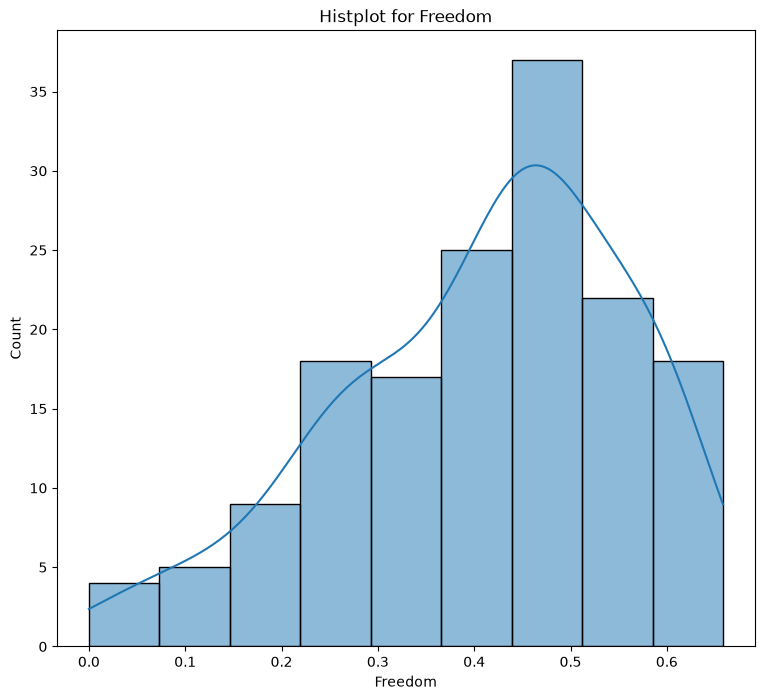

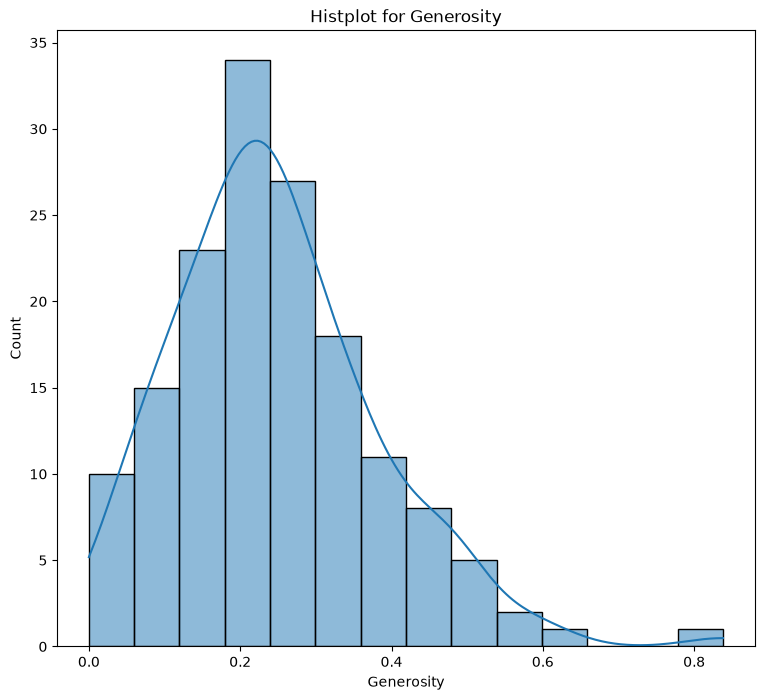

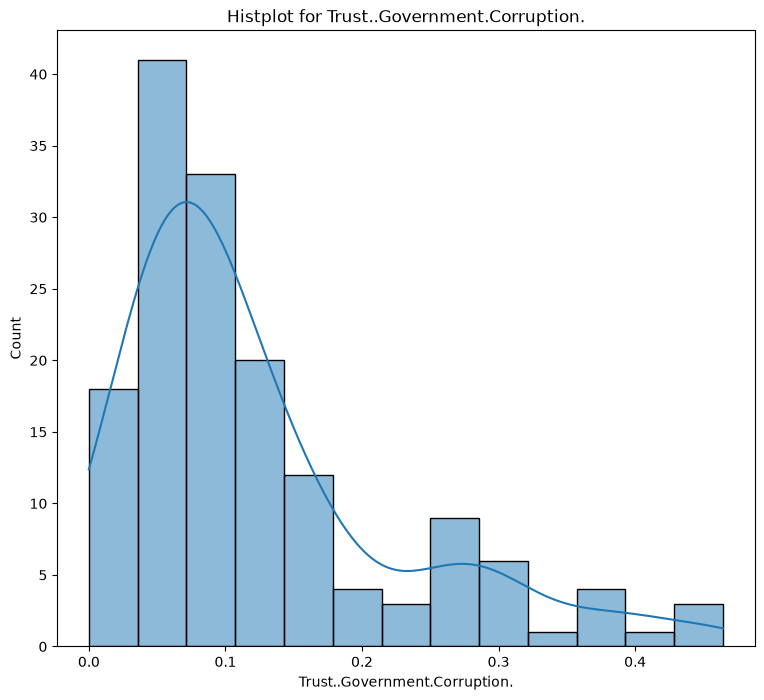

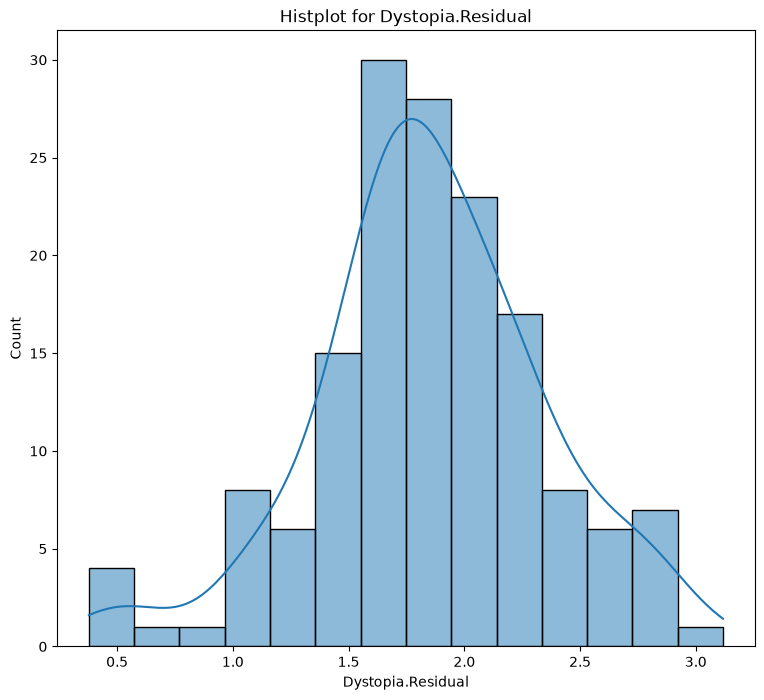

In [13]:
for col in df.select_dtypes(include='number'):
    plt.figure(figsize=(9,8))
    sns.histplot(df[col], kde=True)
    plt.title(f"Histplot for {col}")
    plt.show()

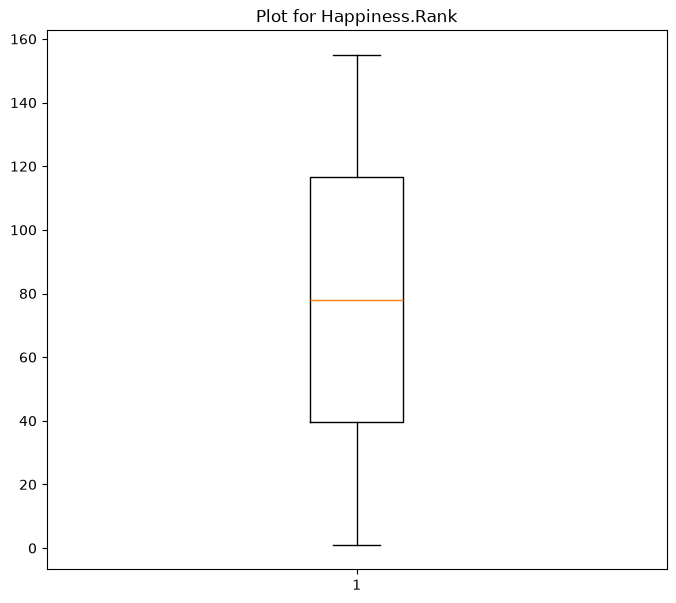

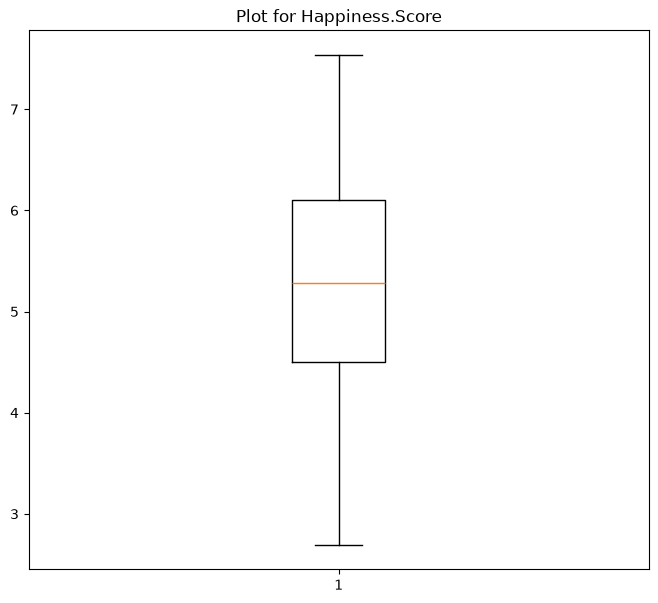

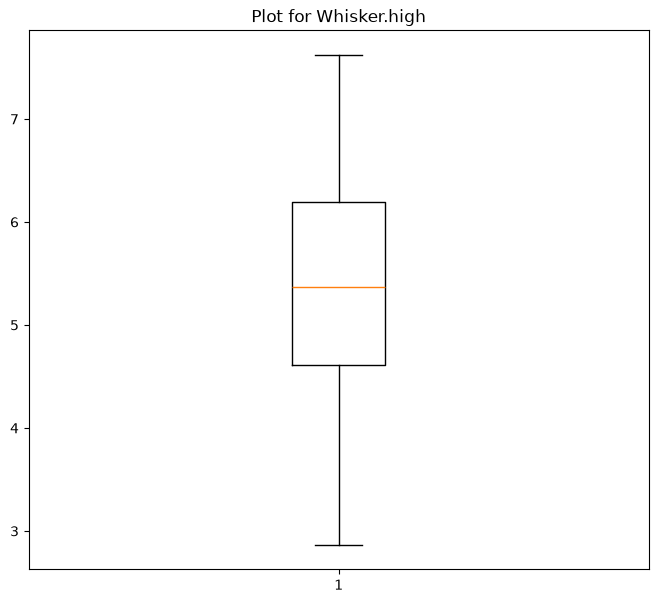

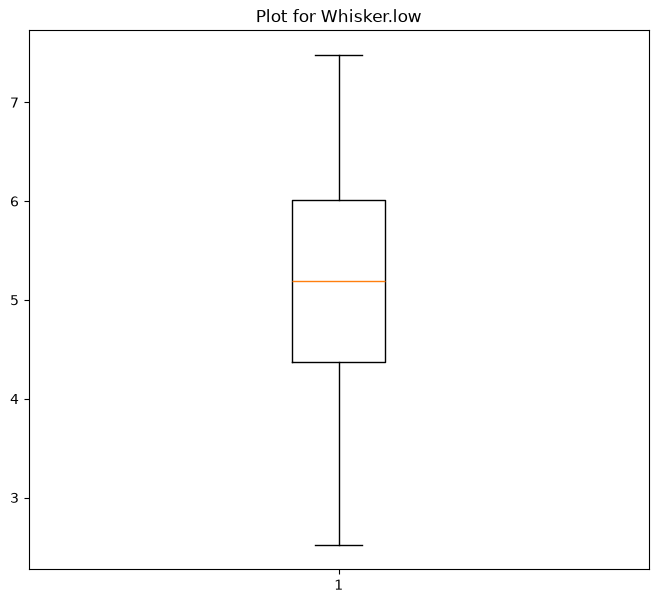

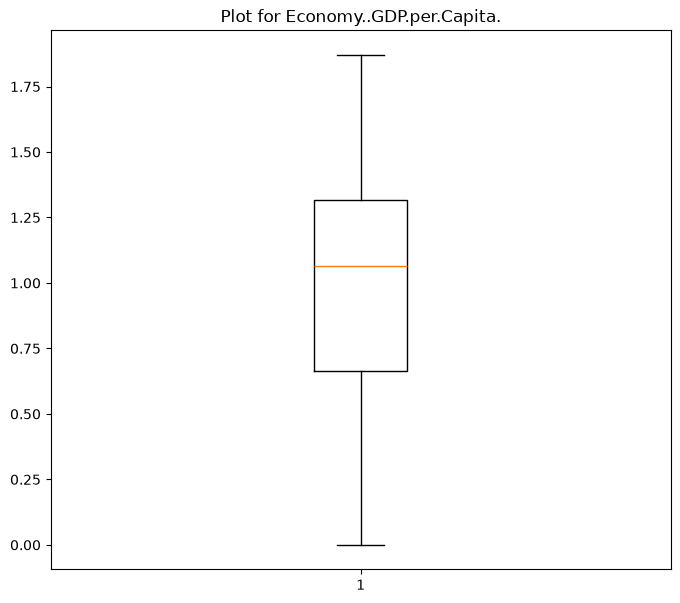

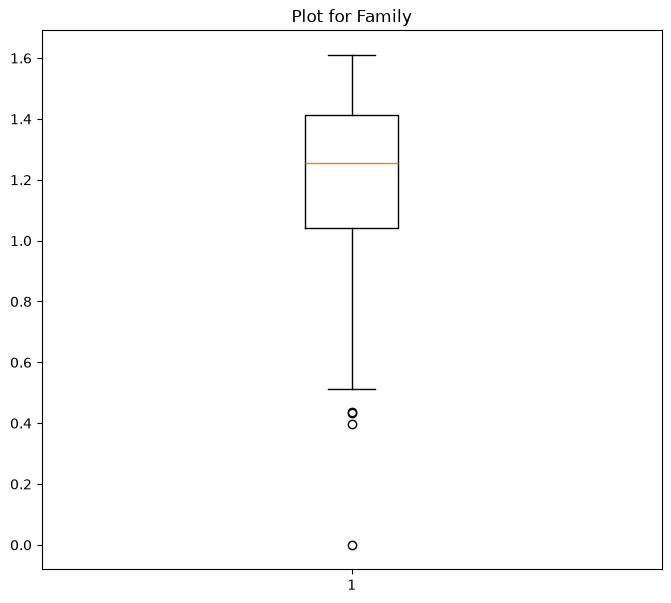

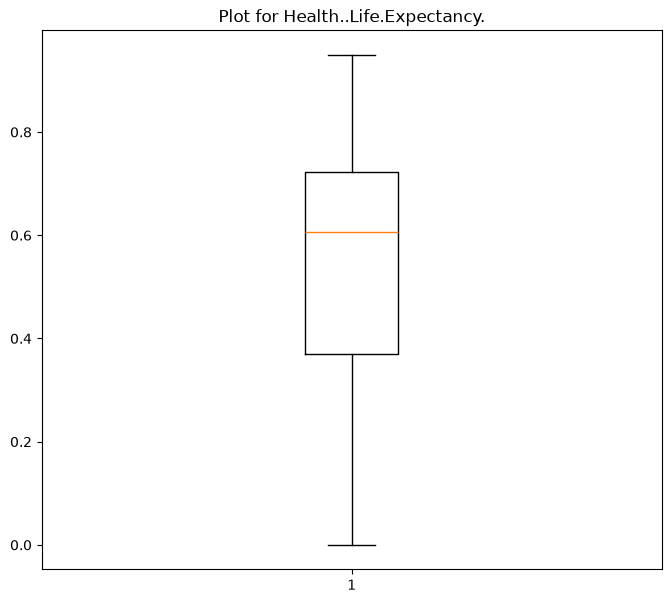

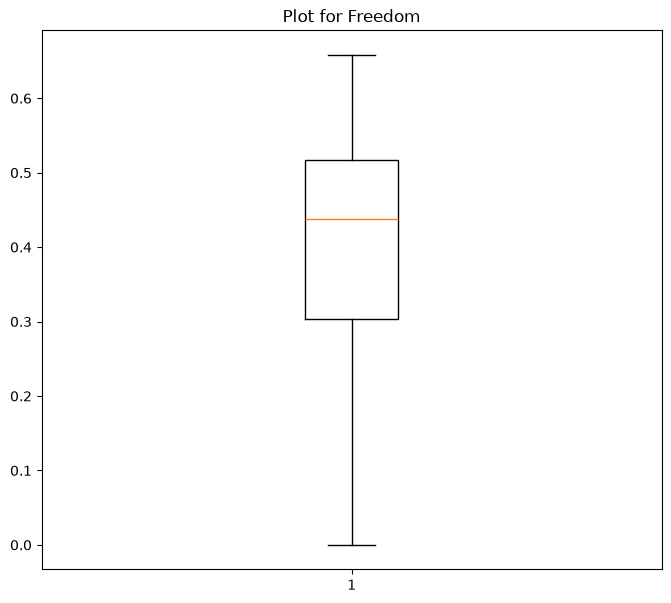

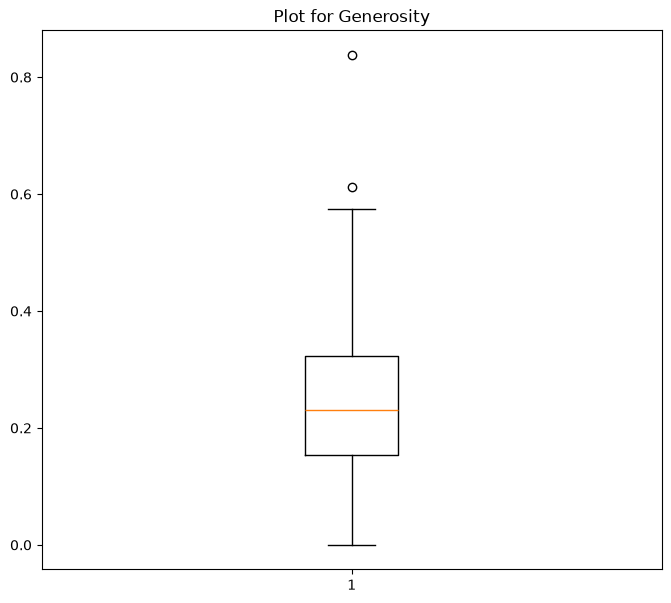

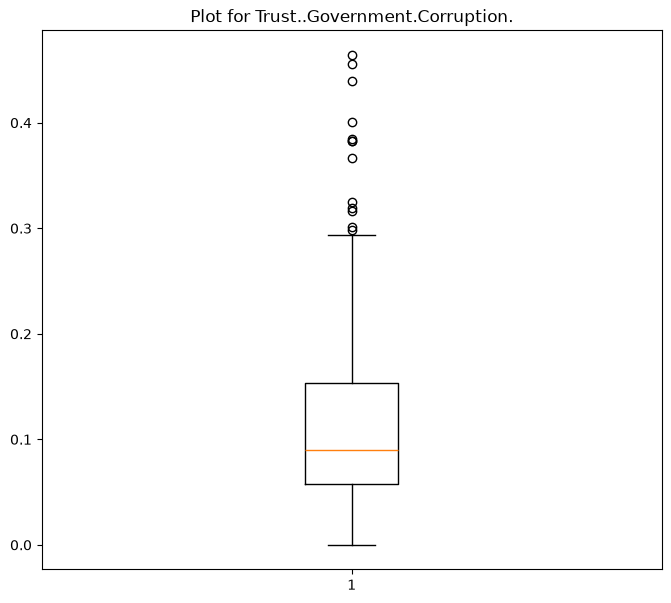

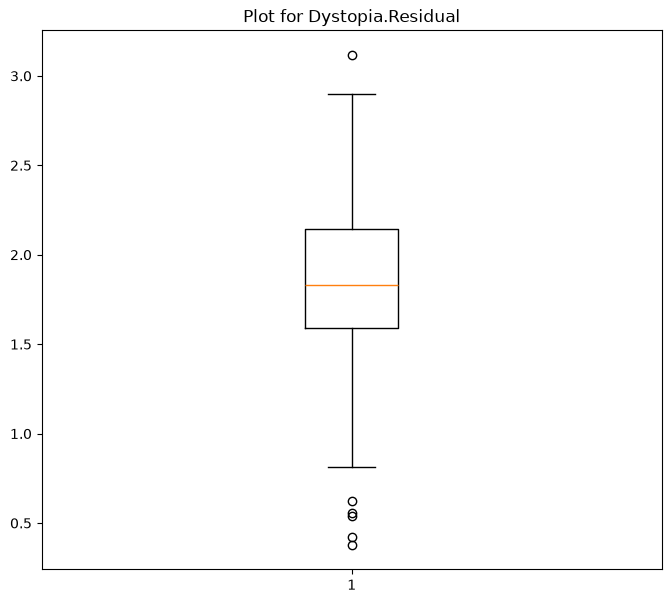

In [15]:
for col in df.select_dtypes(include='number'):
    plt.figure(figsize=(8,7))
    plt.boxplot(x=df[col])
    plt.title(f"Plot for {col}")
    plt.show()

## 3. Scaling the columns

In [16]:
dfcopy = df.copy()

In [17]:
dfcopy.drop(columns=['Happiness.Rank', 'Country'], inplace=True)

In [18]:
dfcopy.columns

Index(['Happiness.Score', 'Whisker.high', 'Whisker.low',
       'Economy..GDP.per.Capita.', 'Family', 'Health..Life.Expectancy.',
       'Freedom', 'Generosity', 'Trust..Government.Corruption.',
       'Dystopia.Residual'],
      dtype='str')

In [19]:
scalar = StandardScaler()
scaled_data = scalar.fit_transform(dfcopy)

scaled_df = pd.DataFrame(scaled_data, columns=dfcopy.columns)

scaled_df.head()

,Happiness.Score,Whisker.high,Whisker.low,Economy..GDP.per.Capita.,Family,Health..Life.Expectancy.,Freedom,Generosity,Trust..Government.Corruption.,Dystopia.Residual
0,1.935996,1.921308,1.948466,1.506188,1.203577,1.038167,1.515836,0.856964,1.903084,0.856296
1,1.922693,1.909902,1.933322,1.186518,1.265036,1.020812,1.452859,0.806856,2.739998,0.929891
2,1.906730,1.946050,1.866469,1.182345,1.472669,1.194259,1.460590,1.702013,0.300066,0.947964
3,1.897861,1.892003,1.901741,1.383442,1.145561,1.298272,1.413155,0.325028,2.406809,0.855673
4,1.875689,1.861301,1.887924,1.093985,1.227057,1.091026,1.398978,-0.010426,2.560800,1.163581


In [20]:
print("Mean of each column: \n ", scaled_df.mean())

print("Standard deviation of each column: \n", scaled_df.std())

Mean of each column: 
  Happiness.Score                 -2.750488e-16
Whisker.high                     0.000000e+00
Whisker.low                      1.833659e-16
Economy..GDP.per.Capita.        -2.750488e-16
Family                           3.667317e-16
Health..Life.Expectancy.        -2.292073e-16
Freedom                          2.750488e-16
Generosity                       1.203339e-16
Trust..Government.Corruption.   -9.168293e-17
Dystopia.Residual                1.375244e-16
dtype: float64
Standard deviation of each column: 
 Happiness.Score                  1.003241
Whisker.high                     1.003241
Whisker.low                      1.003241
Economy..GDP.per.Capita.         1.003241
Family                           1.003241
Health..Life.Expectancy.         1.003241
Freedom                          1.003241
Generosity                       1.003241
Trust..Government.Corruption.    1.003241
Dystopia.Residual                1.003241
dtype: float64


## 4. Deciding the value of K

#### Elbow method

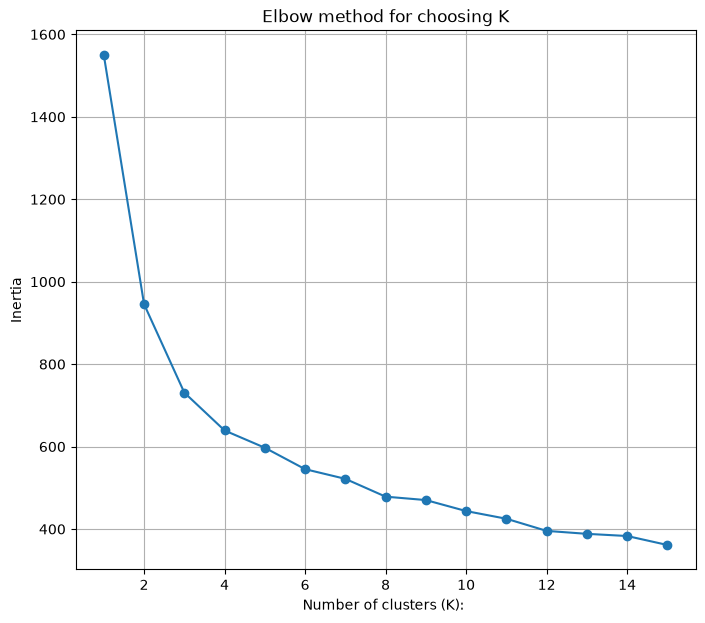

In [21]:
inertia_values = []

for k in range(1, 16):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_df)
    inertia_values.append(kmeans.inertia_)

plt.figure(figsize=(8,7))
plt.plot(range(1, 16), inertia_values, marker="o")
plt.xlabel("Number of clusters (K): ")
plt.ylabel("Inertia")
plt.title("Elbow method for choosing K")
plt.grid(True)
plt.show()

#### Silhouette Score

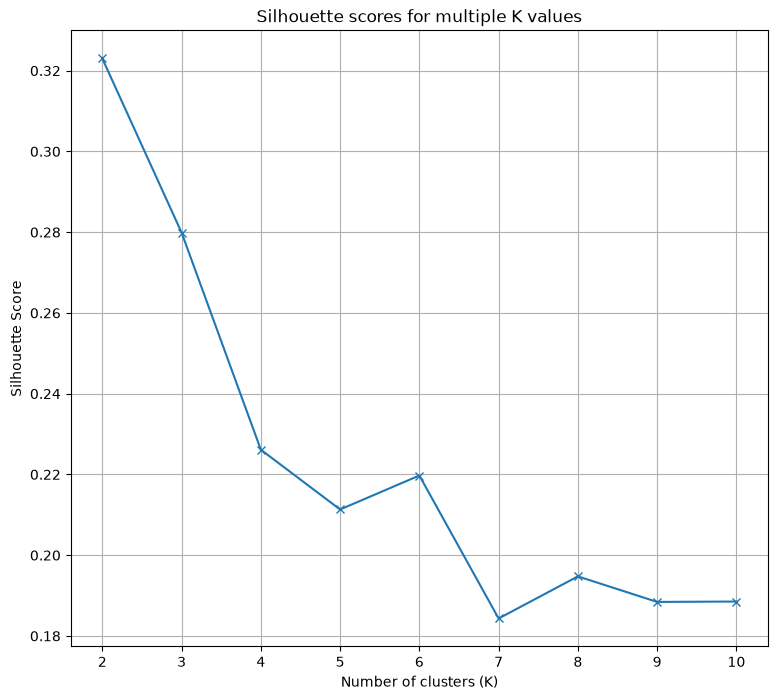

In [22]:
silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_df)
    score = silhouette_score(scaled_df, kmeans.labels_)
    silhouette_scores.append(score)

plt.figure(figsize=(9,8))
plt.plot(range(2, 11), silhouette_scores, marker="x")
plt.xlabel("Number of clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette scores for multiple K values")
plt.grid(True)
plt.show()

Choosing the value of K = 3 based on the elbow method and silhouette score

## 5. Training the model for K = 3

In [25]:
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(scaled_df)

df["Cluster"] = kmeans.labels_

df.head()

,Country,Happiness.Rank,Happiness.Score,Whisker.high,Whisker.low,Economy..GDP.per.Capita.,Family,Health..Life.Expectancy.,Freedom,Generosity,Trust..Government.Corruption.,Dystopia.Residual,Cluster
0,Norway,1,7.537,7.594445,7.479556,1.616463,1.533524,0.796667,0.635423,0.362012,0.315964,2.277027,2
1,Denmark,2,7.522,7.581728,7.462272,1.482383,1.551122,0.792566,0.626007,0.355280,0.400770,2.313707,2
2,Iceland,3,7.504,7.622030,7.385970,1.480633,1.610574,0.833552,0.627163,0.475540,0.153527,2.322715,2
3,Switzerland,4,7.494,7.561772,7.426227,1.564980,1.516912,0.858131,0.620071,0.290549,0.367007,2.276716,2
4,Finland,5,7.469,7.527542,7.410458,1.443572,1.540247,0.809158,0.617951,0.245483,0.382612,2.430182,2


In [26]:
df["Cluster"].value_counts()

Cluster
0    69
1    56
2    30
Name: count, dtype: int64

## 6. PCA Visualization

Before Clustering

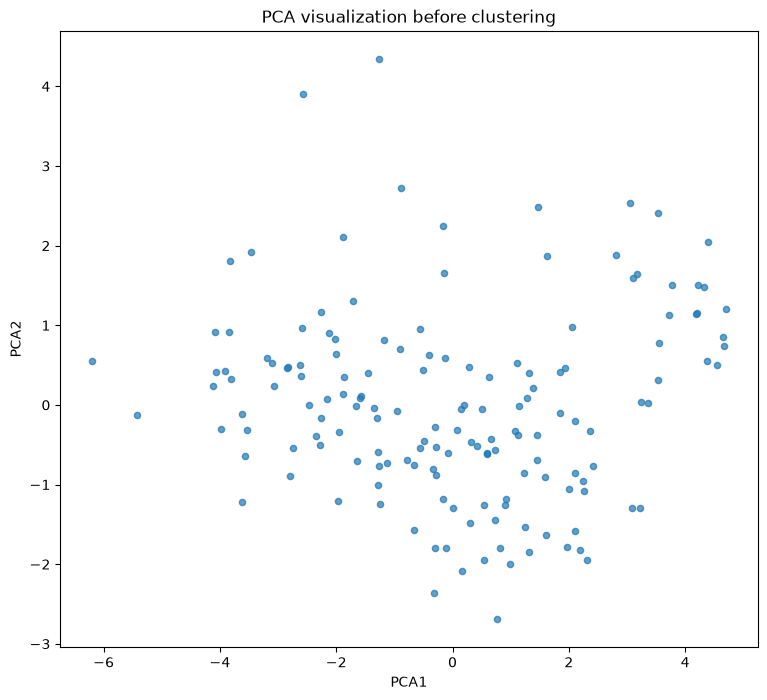

In [27]:
pca = PCA(n_components=2)
pca_components = pca.fit_transform(scaled_df)

plt.figure(figsize=(9,8))
plt.scatter(pca_components[:, 0], pca_components[:, 1], s=20, alpha=0.7)
plt.title("PCA visualization before clustering")
plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.show()

After clustering

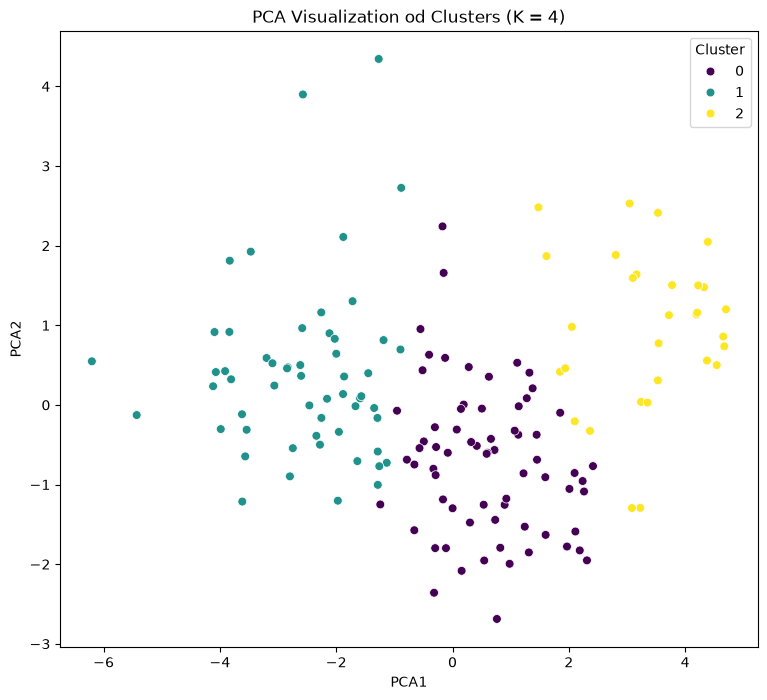

In [28]:
pca = PCA(n_components=2)
pca_components = pca.fit_transform(scaled_df)

pca_df = pd.DataFrame(data=pca_components, columns=["PCA1", "PCA2"])
pca_df["Cluster"] = df["Cluster"]

plt.figure(figsize=(9,8))
sns.scatterplot(x="PCA1", y="PCA2", hue="Cluster", palette="viridis", data=pca_df ,s=40)
plt.title("PCA Visualization od Clusters (K = 4)")
plt.show()

## 7. Cluster Interpretation

In [29]:
cluster_profile = df.drop(columns=["Country", "Happiness.Rank"]).groupby("Cluster").mean()

cluster_profile

,Happiness.Score,Whisker.high,Whisker.low,Economy..GDP.per.Capita.,Family,Health..Life.Expectancy.,Freedom,Generosity,Trust..Government.Corruption.,Dystopia.Residual
Cluster,,,,,,,,,,
0,5.671565,5.767376,5.575754,1.114247,1.297764,0.647789,0.398559,0.194573,0.077882,1.940731
1,4.156571,4.269030,4.044113,0.566696,0.919866,0.310308,0.334410,0.252137,0.100388,1.672704
2,6.858900,6.936528,6.781272,1.467111,1.440698,0.779438,0.571142,0.357390,0.269601,1.973500


2 = Happiest group,
1 = Unhappy group,
0 = Moderately happy group

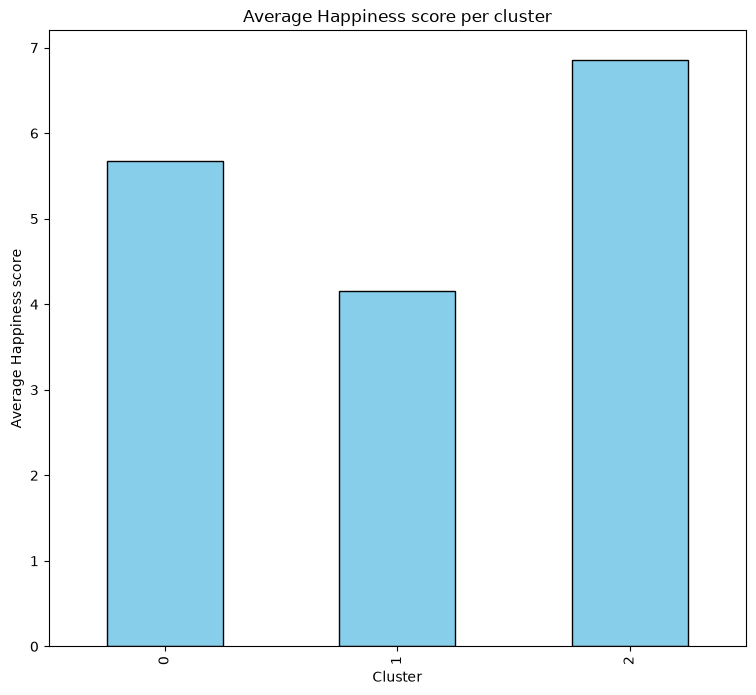

In [30]:
plt.figure(figsize=(9,8))
cluster_profile["Happiness.Score"].plot(kind="bar", color='skyblue', edgecolor="#010101")
plt.title("Average Happiness score per cluster")
plt.xlabel("Cluster")
plt.ylabel("Average Happiness score")
plt.show()

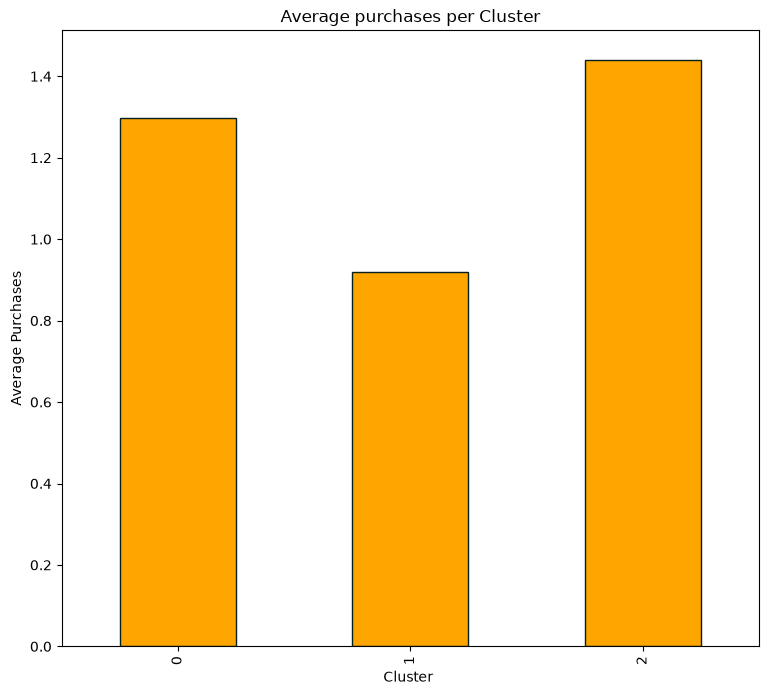

In [ ]:
plt.figure(figsize=(9,8))
cluster_profile["Family"].plot(kind="bar", color="orange", edgecolor="#022020")
plt.title("Average Families per Cluster")
plt.xlabel("Cluster ")
plt.ylabel("Average Family")
plt.show()

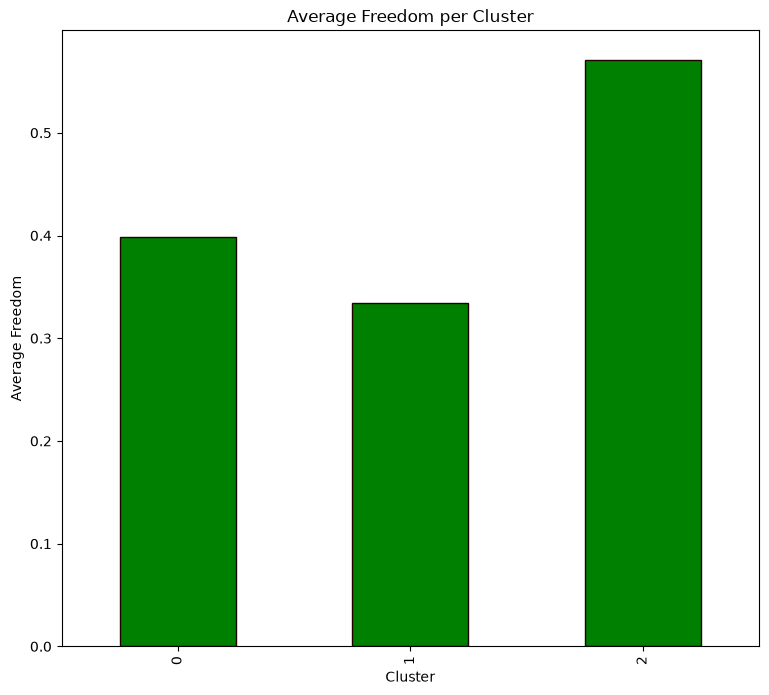

In [37]:
plt.figure(figsize=(9,8))
cluster_profile["Freedom"].plot(kind="bar", color="green", edgecolor="#200202")
plt.title("Average Freedom per Cluster")
plt.xlabel('Cluster')
plt.ylabel("Average Freedom")
plt.show()

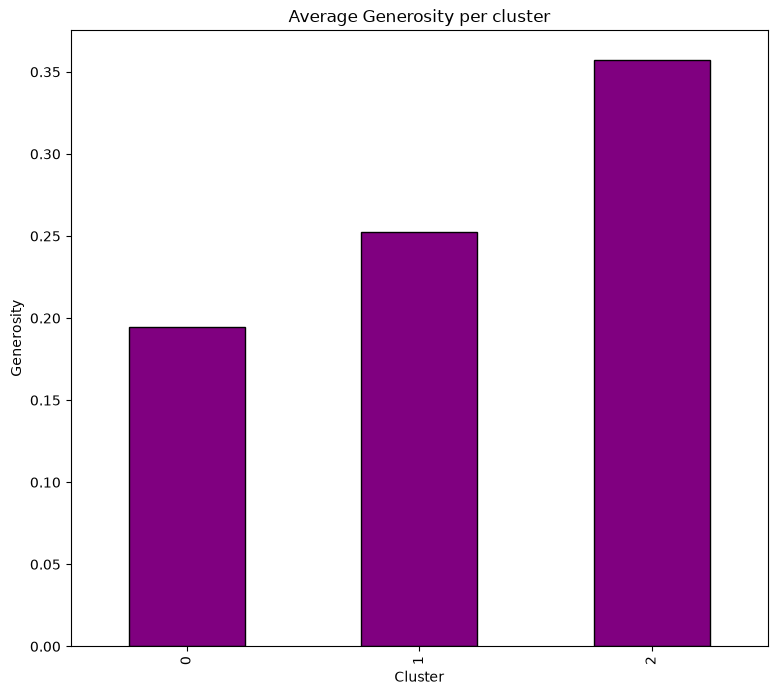

In [36]:
plt.figure(figsize=(9,8))
cluster_profile["Generosity"].plot(kind="bar", color="purple", edgecolor="#010101")
plt.title("Average Generosity per cluster")
plt.xlabel("Cluster")
plt.ylabel("Generosity")
plt.show()

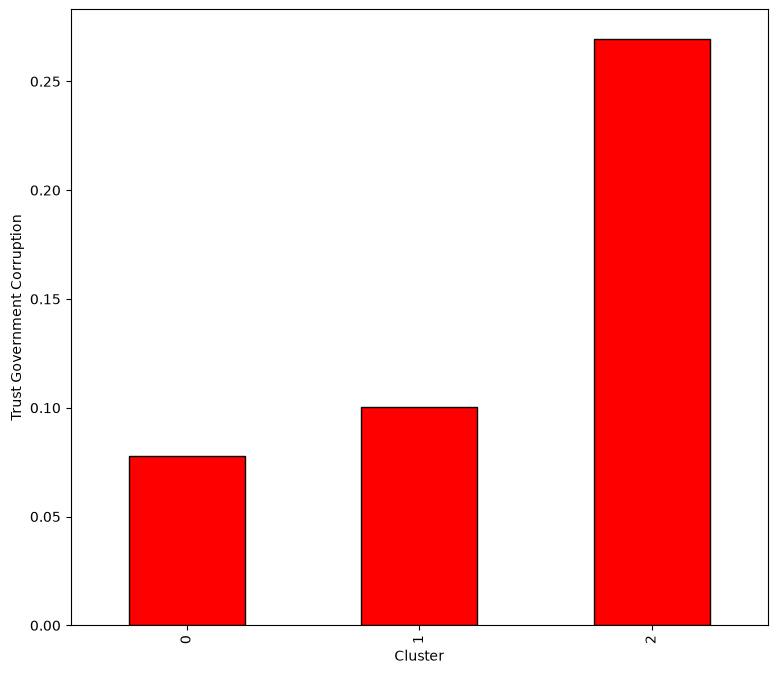

In [35]:
plt.figure(figsize=(9,8))
cluster_profile["Trust..Government.Corruption."].plot(kind="bar", color="red", edgecolor="#030303")
plt.xlabel("Cluster")
plt.ylabel("Trust Government Corruption")
plt.show()

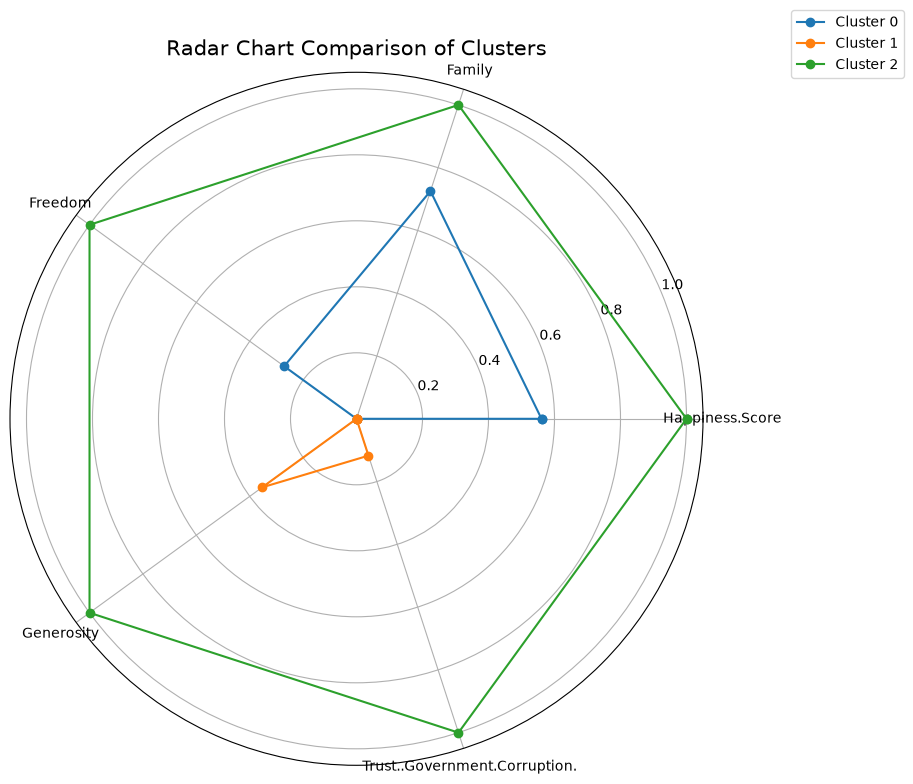

In [38]:
features = ['Happiness.Score', 'Family', 'Freedom', 'Generosity', 'Trust..Government.Corruption.']
    
data = cluster_profile[features]

data_norm = (data - data.min()) / (data.max() - data.min())

num_vars = len(features)

angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

plt.figure(figsize=(9, 9))

for i in range(len(data_norm)):
    values = data_norm.iloc[i].tolist()
    values += values[:1]

    plt.polar(angles, values, marker='o', label=f'Cluster {i}')

plt.xticks(angles[:-1], features)
plt.title("Radar Chart Comparison of Clusters", size=15)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.show()